In [1]:
import os

# Set working directory to project root always
# Works regardless of where the notebook is saved
notebook_dir = os.path.dirname(os.path.abspath('__file__'))
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))
os.chdir(project_root)

print("Working directory set to:", os.getcwd())

Working directory set to: c:\Users\DELL\OneDrive\Documents\SRM\Churn_Analysis


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

In [3]:
df = pd.read_csv(
    'data/banking/Churn_Modelling.csv'
)

print("Shape:", df.shape)

df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print(df.info())
print(df.isnull().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB
None
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [5]:
print(df['Exited'].value_counts())

print(
    round(
        df['Exited']
        .value_counts(normalize=True)*100,
        2
    )
)

Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.63
1    20.37
Name: proportion, dtype: float64


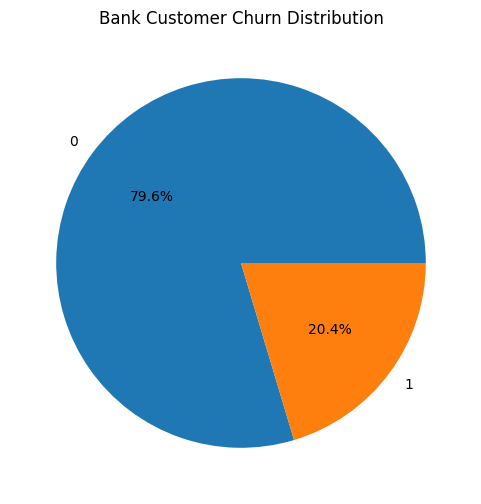

In [6]:
plt.figure(figsize=(6,6))

df['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')

plt.title(
    'Bank Customer Churn Distribution'
)

plt.show()

In [7]:
geo_churn = pd.crosstab(
    df['Geography'],
    df['Exited']
)

print(geo_churn)

Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413


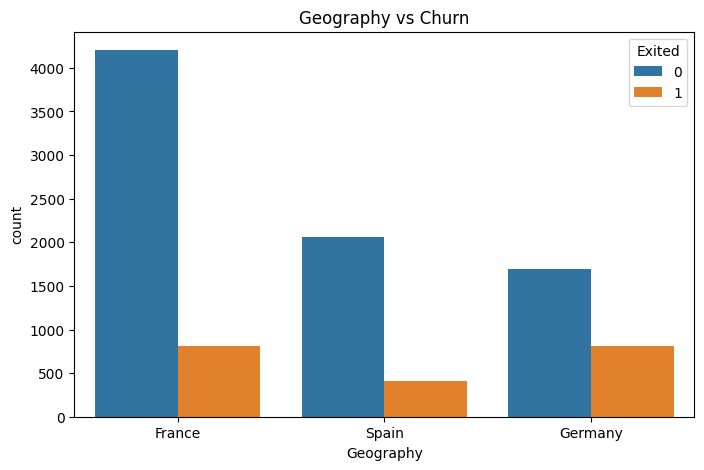

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Geography',
    hue='Exited'
)

plt.title(
    'Geography vs Churn'
)

plt.show()

In [9]:
gender_churn = pd.crosstab(
    df['Gender'],
    df['Exited']
)

print(gender_churn)

Exited     0     1
Gender            
Female  3404  1139
Male    4559   898


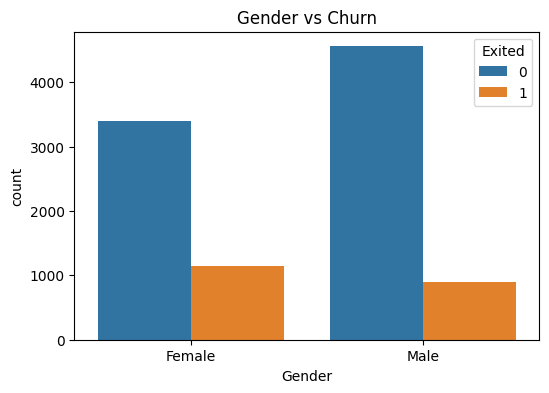

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Gender',
    hue='Exited'
)

plt.title(
    'Gender vs Churn'
)

plt.show()

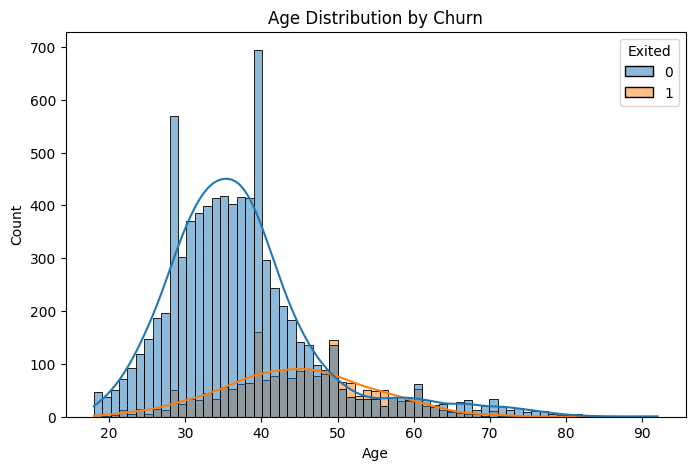

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Age',
    hue='Exited',
    kde=True
)

plt.title(
    'Age Distribution by Churn'
)

plt.show()

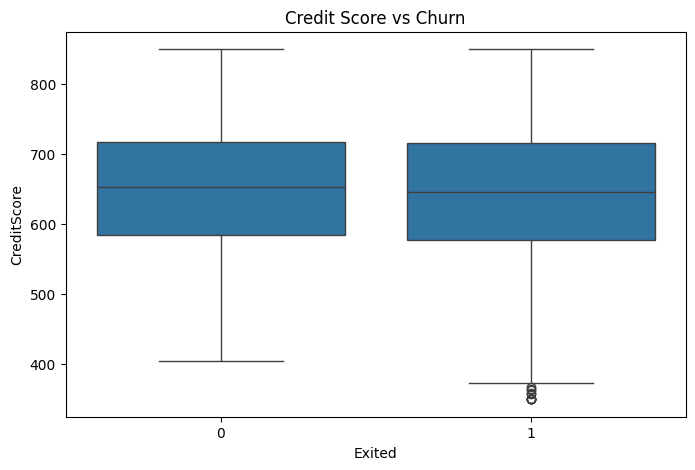

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Exited',
    y='CreditScore'
)

plt.title(
    'Credit Score vs Churn'
)

plt.show()

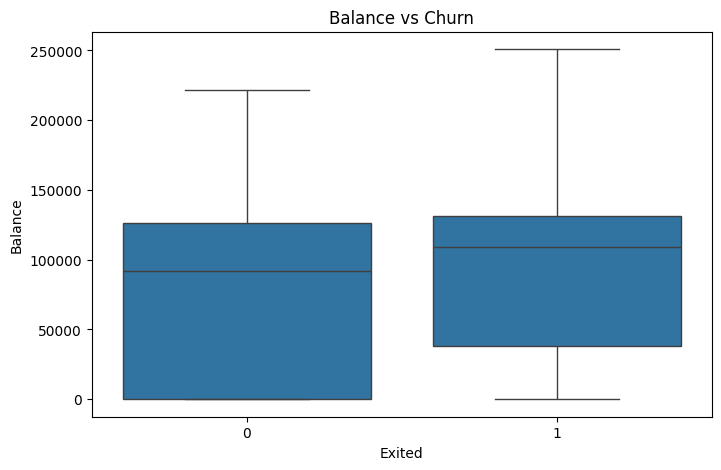

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Exited',
    y='Balance'
)

plt.title(
    'Balance vs Churn'
)

plt.show()

In [14]:
active_rate = (
    df.groupby(
        'IsActiveMember'
    )['Exited']
    .mean()*100
)

print(
    active_rate.round(2)
)

IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64


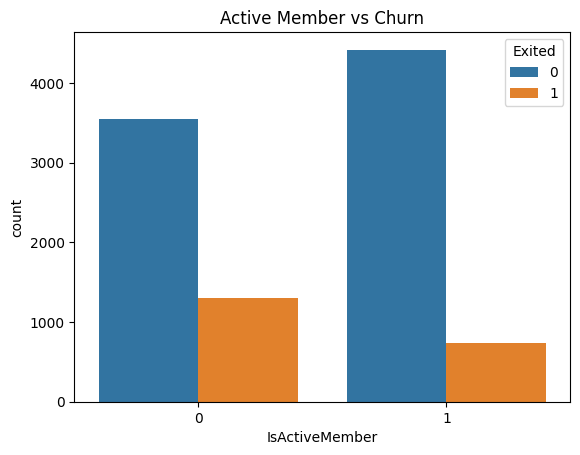

In [15]:
sns.countplot(
    data=df,
    x='IsActiveMember',
    hue='Exited'
)

plt.title(
    'Active Member vs Churn'
)

plt.show()

In [16]:
product_rate = (
    df.groupby(
        'NumOfProducts'
    )['Exited']
    .mean()*100
)

print(
    product_rate.round(2)
)

NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64


In [17]:
temp = df.drop(
    columns=[
        'RowNumber',
        'CustomerId',
        'Surname'
    ]
)

In [18]:
from sklearn.preprocessing import LabelEncoder

eda_df = temp.copy()

le = LabelEncoder()

eda_df['Gender'] = le.fit_transform(
    eda_df['Gender']
)

eda_df['Geography'] = le.fit_transform(
    eda_df['Geography']
)

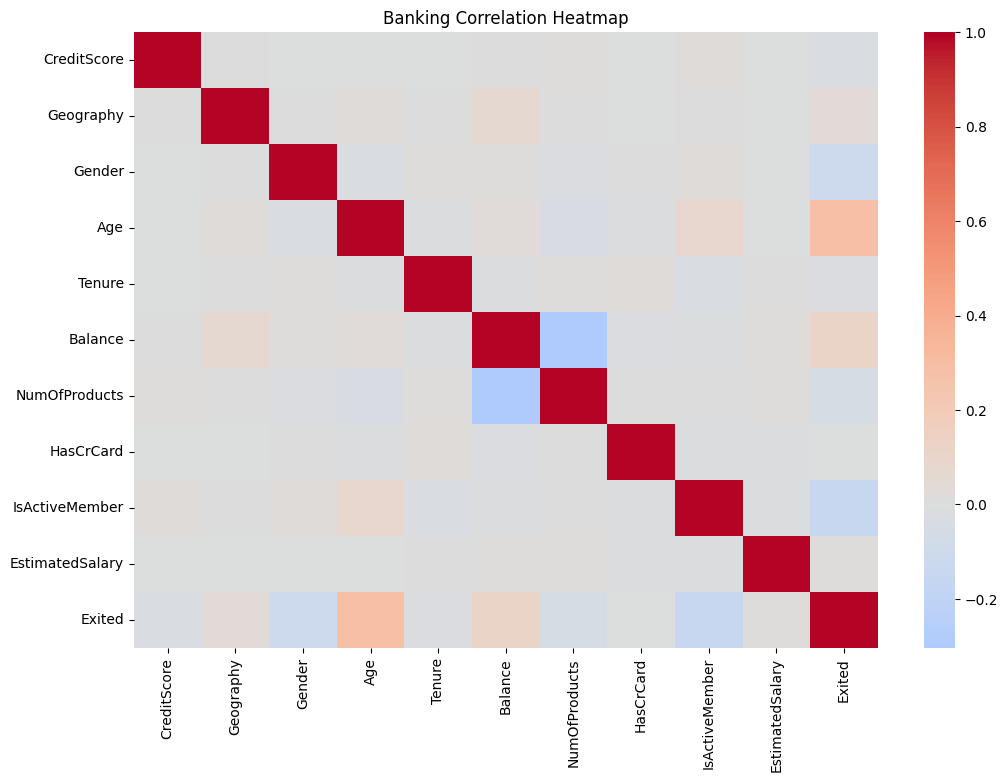

In [19]:
corr = eda_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title(
    'Banking Correlation Heatmap'
)

plt.show()

In [20]:
churn_corr = (
    corr['Exited']
    .sort_values(
        ascending=False
    )
)

print(churn_corr)

Exited             1.000000
Age                0.285323
Balance            0.118533
Geography          0.035943
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
Gender            -0.106512
IsActiveMember    -0.156128
Name: Exited, dtype: float64


In [21]:
churn_corr

Exited             1.000000
Age                0.285323
Balance            0.118533
Geography          0.035943
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
Gender            -0.106512
IsActiveMember    -0.156128
Name: Exited, dtype: float64